In [ ]:
pip install tensorflow keras numpy pandas matplotlib seaborn opencv-python streamlit scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.1 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import EfficientNetB0

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Dataset.zip"
extract_path = "/content/drive/MyDrive/Fish_Classification/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_data = "/content/drive/MyDrive/Fish_Classification/dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test"
train_data = "/content/drive/MyDrive/Fish_Classification/dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/train"
val_data = "/content/drive/MyDrive/Fish_Classification/dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val"

# Resize for validation
val_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale
val_generator = val_datagen.flow_from_directory(
    val_data,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Resize for test data
test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale
test_generator = test_datagen.flow_from_directory(
    test_data,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Apply augumentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0,1]
    rotation_range=40,  # Random rotation
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,  # Shear transformation
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True  # Flip images
)
train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(224, 224),  # Resize all images
    batch_size=32,
    class_mode='categorical'
)

Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Found 6225 images belonging to 11 classes.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes for classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "/content/drive/MyDrive/CNN_F"

# Load the pre-trained VGG16 model
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)  # Use number of classes from augmented data

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model using augmented dataset
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save the trained model
model.save(f"{save_path}/vgg16_trained_model.h5")
print(f"Model saved successfully at {save_path}/vgg16_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_vgg16.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_vgg16.pkl")

# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 4084s 21s/step - accuracy: 0.4744 - loss: 2.1837 - val_accuracy: 0.8919 - val_loss: 0.3665
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 4030s 21s/step - accuracy: 0.8533 - loss: 0.4624 - val_accuracy: 0.9240 - val_loss: 0.2673
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 4028s 21s/step - accuracy: 0.8790 - loss: 0.3609 - val_accuracy: 0.9542 - val_loss: 0.1375


Model saved successfully at /content/drive/MyDrive/CNN_F/vgg16_trained_model.h5
Training history saved successfully at /content/drive/MyDrive/CNN_F/training_history_vgg16.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 1761s 17s/step - accuracy: 0.9673 - loss: 0.1119
Test accuracy: 0.9702


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "/content/drive/MyDrive/CNN_F"

# Load the pre-trained ResNet50 model
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save model
model.save(f"{save_path}/resnet50_trained_model.h5")
print(f"Model saved successfully at {save_path}/resnet50_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_resnet50.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_resnet50.pkl")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 1391s 7s/step - accuracy: 0.1743 - loss: 5.5991 - val_accuracy: 0.2729 - val_loss: 1.9833
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 1397s 7s/step - accuracy: 0.2662 - loss: 2.1403 - val_accuracy: 0.3022 - val_loss: 1.8671
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 1359s 7s/step - accuracy: 0.2996 - loss: 1.9969 - val_accuracy: 0.3526 - val_loss: 1.9331


Model saved successfully at /content/drive/MyDrive/CNN_F/resnet50_trained_model.h5
Training history saved successfully at /content/drive/MyDrive/CNN_F/training_history_resnet50.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 536s 5s/step - accuracy: 0.3307 - loss: 1.9161
Test accuracy: 0.3335


In [ ]:
import tensorflow as tf
import pickle

# Define save path
save_path = "/content/drive/MyDrive/CNN_F"

# Load the trained model
model = tf.keras.models.load_model(f"{save_path}/resnet50_trained_model.h5")
print("Model loaded successfully!")

# Load training history
with open(f"{save_path}/training_history_resnet50.pkl", "rb") as f:
    history = pickle.load(f)
print("Training history loaded successfully!")

# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

Model loaded successfully!
Training history loaded successfully!
100/100 ━━━━━━━━━━━━━━━━━━━━ 541s 5s/step - accuracy: 0.3212 - loss: 1.9429
Test accuracy: 0.3335


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "/content/drive/MyDrive/CNN_F"

# Load the pre-trained MobileNet model
base_model = MobileNet(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save model
model.save(f"{save_path}/mobilenet_trained_model.h5")
print(f"Model saved successfully at {save_path}/mobilenet_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_mobilenet.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_mobilenet.pkl")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 476s 2s/step - accuracy: 0.6851 - loss: 5.4785 - val_accuracy: 0.9652 - val_loss: 0.1151
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.9355 - loss: 0.1970 - val_accuracy: 0.9808 - val_loss: 0.0664
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 472s 2s/step - accuracy: 0.9657 - loss: 0.1117 - val_accuracy: 0.9817 - val_loss: 0.0682


Model saved successfully at /content/drive/MyDrive/CNN_F/mobilenet_trained_model.h5
Training history saved successfully at /content/drive/MyDrive/CNN_F/training_history_mobilenet.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9845 - loss: 0.0454
Test accuracy: 0.9834


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "/content/drive/MyDrive/CNN_F"

# Load the pre-trained InceptionV3 model
base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save model
model.save(f"{save_path}/inceptionv3_trained_model.h5")
print(f"Model saved successfully at {save_path}/inceptionv3_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_inceptionv3.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_inceptionv3.pkl")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 964s 5s/step - accuracy: 0.5762 - loss: 12.5697 - val_accuracy: 0.9093 - val_loss: 0.3216
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 982s 5s/step - accuracy: 0.8855 - loss: 0.4516 - val_accuracy: 0.9203 - val_loss: 0.2513
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 977s 5s/step - accuracy: 0.8964 - loss: 0.3535 - val_accuracy: 0.9441 - val_loss: 0.2059


Model saved successfully at /content/drive/MyDrive/CNN_F/inceptionv3_trained_model.h5
Training history saved successfully at /content/drive/MyDrive/CNN_F/training_history_inceptionv3.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 374s 4s/step - accuracy: 0.9542 - loss: 0.1548
Test accuracy: 0.9536


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "/content/drive/MyDrive/CNN_F"

# Load the pre-trained EfficientNetB0 model
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save model
model.save(f"{save_path}/efficientnetb0_trained_model.h5")
print(f"Model saved successfully at {save_path}/efficientnetb0_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_efficientnetb0.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_efficientnetb0.pkl")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 650s 3s/step - accuracy: 0.1152 - loss: 9.0465 - val_accuracy: 0.1712 - val_loss: 2.3789
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 681s 3s/step - accuracy: 0.1738 - loss: 2.3726 - val_accuracy: 0.1712 - val_loss: 2.3606
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 639s 3s/step - accuracy: 0.1725 - loss: 2.3595 - val_accuracy: 0.1712 - val_loss: 2.3470


Model saved successfully at /content/drive/MyDrive/CNN_F/efficientnetb0_trained_model.h5
Training history saved successfully at /content/drive/MyDrive/CNN_F/training_history_efficientnetb0.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 266s 3s/step - accuracy: 0.1499 - loss: 2.3505
Test accuracy: 0.1632


100/100 ━━━━━━━━━━━━━━━━━━━━ 1815s 18s/step - accuracy: 0.9733 - loss: 0.1062
100/100 ━━━━━━━━━━━━━━━━━━━━ 1812s 18s/step


100/100 ━━━━━━━━━━━━━━━━━━━━ 592s 6s/step - accuracy: 0.3141 - loss: 1.9632
100/100 ━━━━━━━━━━━━━━━━━━━━ 592s 6s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


100/100 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9819 - loss: 0.0594
100/100 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step


100/100 ━━━━━━━━━━━━━━━━━━━━ 401s 4s/step - accuracy: 0.9562 - loss: 0.1633
100/100 ━━━━━━━━━━━━━━━━━━━━ 396s 4s/step


100/100 ━━━━━━━━━━━━━━━━━━━━ 267s 3s/step - accuracy: 0.1678 - loss: 2.3455
100/100 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step

Model: VGG16
Accuracy: 0.9702
Precision: 0.1032
Recall: 0.1032
F1-Score: 0.1032
Confusion Matrix:
[[82  2 52 53 52 44 42 41 54 42 56]
 [ 3  0  2  0  2  0  4  0  1  1  0]
 [43  1 26 22 28 32 23 31 35 32 25]
 [56  1 21 34 25 32 25 30 26 29 26]
 [38  2 28 20 27 31 19 29 23 31 38]
 [52  0 23 25 30 27 27 30 21 34 22]
 [48  1 32 30 25 21 22 22 30 26 16]
 [49  1 29 30 31 25 20 39 33 36 34]
 [46  1 33 38 20 30 28 30 23 21 19]
 [45  0 25 29 26 31 25 31 24 25 32]
 [59  0 20 36 23 25 29 30 25 21 24]]

Model: ResNet50
Accuracy: 0.3335
Precision: 0.0914
Recall: 0.0948
F1-Score: 0.0694
Confusion Matrix:
[[ 40   0  22   0 133   1   0  10 207  34  73]
 [  3   0   3   0   3   0   0   0   1   1   2]
 [ 17   0  19   0  84   0   0   2 105  22  49]
 [ 31   0  16   0  70   2   0   7 118  19  42]
 [ 27   0  13   0  73   1   0   4 113  18  37]
 [ 18   0  11   0  80   1   0   8 105  17  51]
 [

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


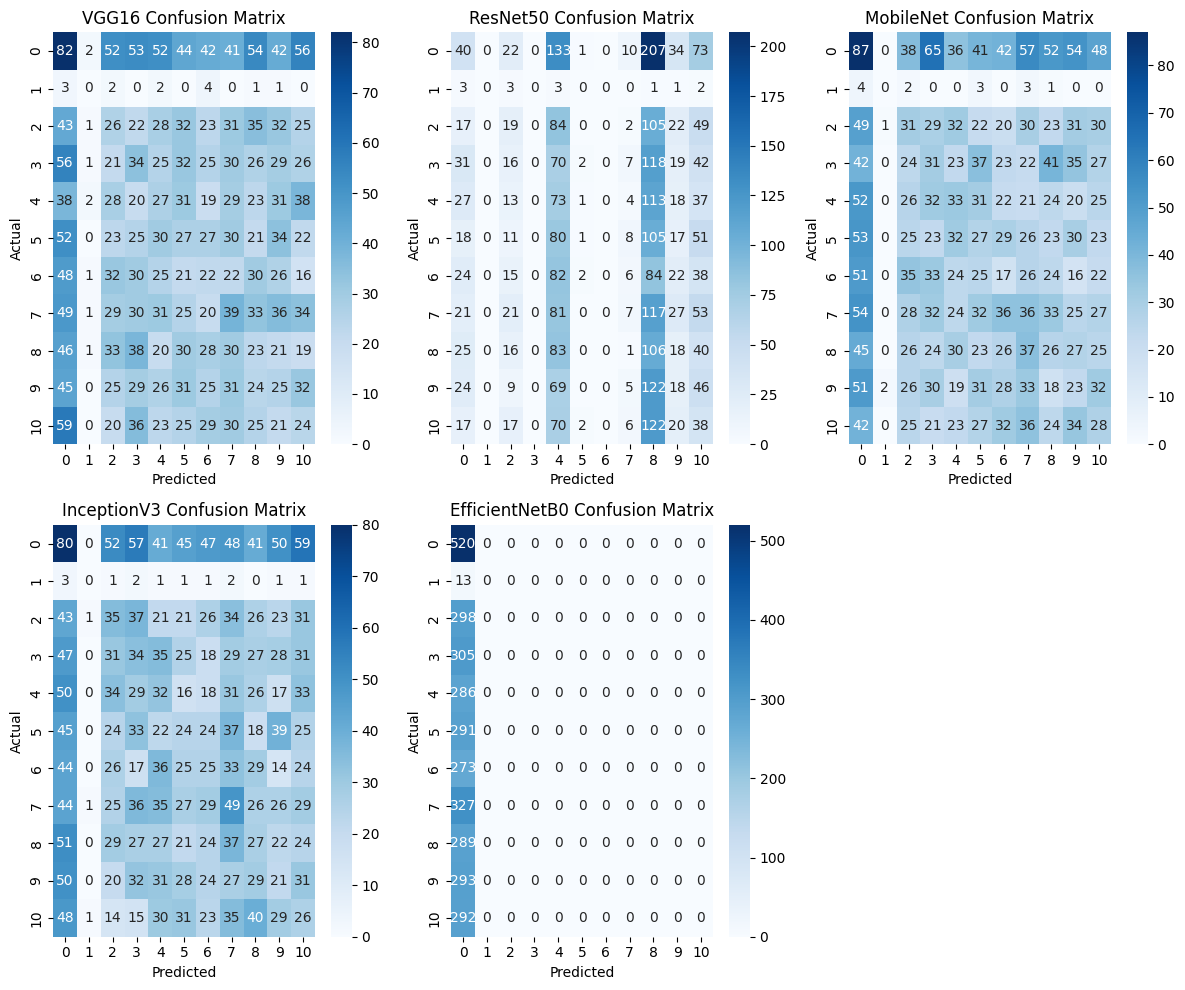

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Dictionary of models
models = {
    "VGG16": "/content/drive/MyDrive/CNN_F/vgg16_trained_model.h5",
    "ResNet50": "/content/drive/MyDrive/CNN_F/resnet50_trained_model.h5",
    "MobileNet": "/content/drive/MyDrive/CNN_F/mobilenet_trained_model.h5",
    "InceptionV3": "/content/drive/MyDrive/CNN_F/inceptionv3_trained_model.h5",
    "EfficientNetB0": "/content/drive/MyDrive/CNN_F/efficientnetb0_trained_model.h5",
}

# Store results
metrics = {}

for model_name, model_path in models.items():
    # Load model
    model = tf.keras.models.load_model(model_path)

    # Evaluate model on test data
    loss, acc = model.evaluate(test_generator)

    # Predict on test data
    y_pred_probs = model.predict(test_generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_generator.classes  # Get true labels from the generator

    # Compute metrics
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    cm = confusion_matrix(y_true, y_pred)

    # Store results
    metrics[model_name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Confusion Matrix": cm
    }

# Display results
for model, scores in metrics.items():
    print(f"\nModel: {model}")
    for metric, value in scores.items():
        if metric == "Confusion Matrix":
            print(f"{metric}:\n{value}")
        else:
            print(f"{metric}: {value:.4f}")

# Plot Confusion Matrices
plt.figure(figsize=(12, 10))
for i, (model, scores) in enumerate(metrics.items()):
    plt.subplot(2, 3, i + 1)
    sns.heatmap(scores["Confusion Matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
best_model = max(metrics.items(), key=lambda x: x[1]["Accuracy"])

# Print the best model in the next cell
print(f"\nBest Model: {best_model[0]}")
print(f"Accuracy: {best_model[1]['Accuracy']:.4f}")
print(f"Precision: {best_model[1]['Precision']:.4f}")
print(f"Recall: {best_model[1]['Recall']:.4f}")
print(f"F1-Score: {best_model[1]['F1-Score']:.4f}")


Best Model: MobileNet
Accuracy: 0.9834
Precision: 0.1060
Recall: 0.1064
F1-Score: 0.1062


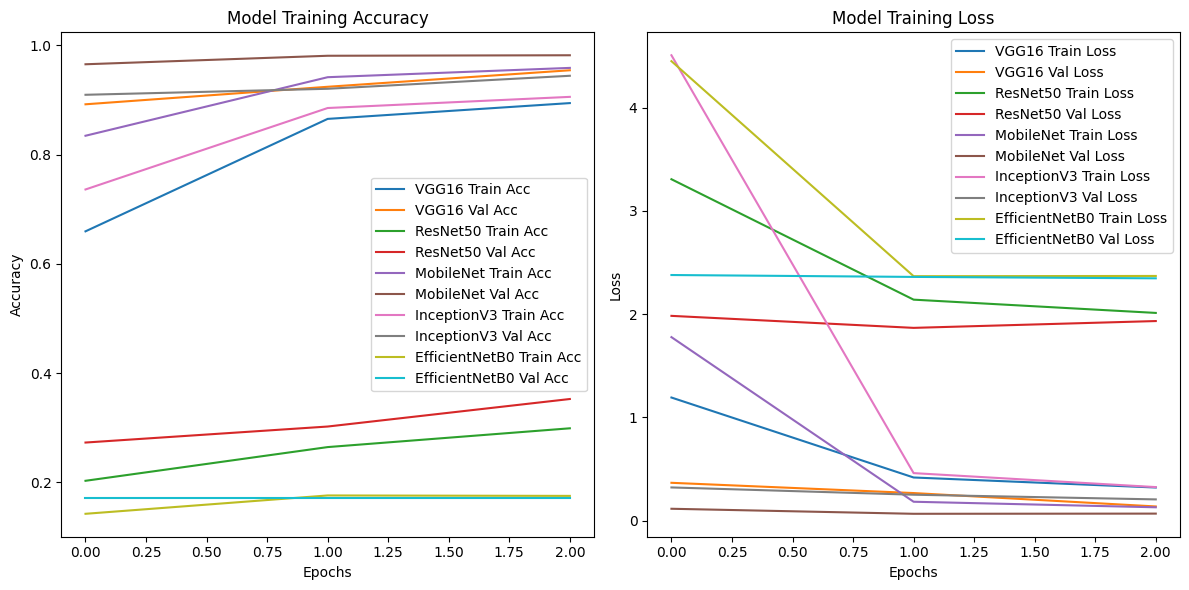

In [ ]:
import pickle
import matplotlib.pyplot as plt

# List of model names and corresponding files
model_files = {
    "VGG16": "/content/drive/MyDrive/CNN_F/training_history_vgg16.pkl",
    "ResNet50": "/content/drive/MyDrive/CNN_F/training_history_resnet50.pkl",
    "MobileNet": "/content/drive/MyDrive/CNN_F/training_history_mobilenet.pkl",
    "InceptionV3": "/content/drive/MyDrive/CNN_F/training_history_inceptionv3.pkl",
    "EfficientNetB0": "/content/drive/MyDrive/CNN_F/training_history_efficientnetb0.pkl"
}

# Function to load history
def load_history(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

# Plot training history
plt.figure(figsize=(12, 6))
for model, file in model_files.items():
    history = load_history(file)

    # Extract accuracy and loss
    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    train_loss = history['loss']
    val_loss = history['val_loss']

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(train_acc, label=f"{model} Train Acc")
    plt.plot(val_acc, label=f"{model} Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Model Training Accuracy")
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(train_loss, label=f"{model} Train Loss")
    plt.plot(val_loss, label=f"{model} Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Model Training Loss")
    plt.legend()

# Show plots
plt.tight_layout()
plt.show()